<a href="https://colab.research.google.com/github/Scf300/TELECOMX_LATAM_PARTE_2/blob/main/TELECOMX_LATAM_PARTE_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X - Parte 2

## Predicción de cancelación de clientes (Churn)

En este proyecto se realiza:

- Carga y limpieza de datos.
- Eliminación de variables no útiles para el modelado.
- Codificación de variables categóricas.
- Análisis de desbalance de clases.
- Visualización de correlaciones y relaciones con la cancelación.
- División en entrenamiento y prueba.
- Entrenamiento de dos modelos:
  - Regresión Logística
  - Random Forest
- Evaluación con:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Matriz de confusión
- Análisis de variables relevantes.
- Informe final con hallazgos y estrategias de retención.


In [70]:
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

try:
    from imblearn.over_sampling import SMOTE
    smote_disponible = True
except Exception:
    smote_disponible = False

print("Librerías cargadas correctamente.")
print("SMOTE disponible:", smote_disponible)


Librerías cargadas correctamente.
SMOTE disponible: True


## 1. Extracción y carga de datos


In [71]:
url = "https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json"
raw_url = url.replace("github.com", "raw.githubusercontent.com").replace("/blob", "")

response = requests.get(raw_url)
response.raise_for_status()
data = response.json()

df_raw = pd.DataFrame(data)
df_raw.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## 2. Normalización de columnas anidadas


In [72]:
customer_df = pd.json_normalize(df_raw["customer"])
phone_df = pd.json_normalize(df_raw["phone"])
internet_df = pd.json_normalize(df_raw["internet"])
account_df = pd.json_normalize(df_raw["account"])

df = pd.concat(
    [
        df_raw[["customerID", "Churn"]],
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    axis=1
)

df.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [73]:
df = df.rename(columns={
    "Charges.Monthly": "Charges_Monthly",
    "Charges.Total": "Charges_Total"
})

df.columns


Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges_Monthly',
       'Charges_Total'],
      dtype='object')

## 3. Limpieza y tratamiento de datos


In [74]:
print("Dimensiones iniciales:", df.shape)
print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicados:", df.duplicated().sum())


Dimensiones iniciales: (7267, 21)

Tipos de datos:


,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object



Valores nulos:


,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0



Duplicados: 0


In [75]:
df = df.drop_duplicates()

df["Charges_Total"] = pd.to_numeric(df["Charges_Total"], errors="coerce")
df["Charges_Monthly"] = pd.to_numeric(df["Charges_Monthly"], errors="coerce")
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")

df["Charges_Total"] = df["Charges_Total"].fillna(df["Charges_Total"].median())

if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df["Cuentas_Diarias"] = df["Charges_Monthly"] / 30

print("Dimensiones tras limpieza:", df.shape)
display(df.head())


Dimensiones tras limpieza: (7267, 22)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## 4. Eliminación de columnas irrelevantes
Se elimina `customerID` porque es un identificador único y no aporta valor predictivo.


In [76]:
df_ml = df.copy()

if "customerID" in df_ml.columns:
    df_ml = df_ml.drop(columns=["customerID"])

print("Columnas finales para análisis/modelado:")
display(df_ml.columns.tolist())


Columnas finales para análisis/modelado:


['Churn',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Charges_Monthly',
 'Charges_Total',
 'Cuentas_Diarias']

## 5. Análisis exploratorio inicial


In [77]:
display(df_ml.describe(include="all"))


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Cuentas_Diarias
count,7043.000000,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267.000000,7267.000000
unique,NaN,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,NaN
top,NaN,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,NaN
freq,NaN,3675,NaN,3749,5086,NaN,6560,3495,3198,3608,...,3195,3582,2896,2870,4005,4311,2445,NaN,NaN,NaN
mean,0.265370,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,2279.287581,2.157337
std,0.441561,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,2267.178963,1.004319
min,0.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,0.608333
25%,0.000000,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,401.400000,1.180833
50%,0.000000,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,1391.000000,2.343333
75%,1.000000,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,3778.525000,2.995833


/tmp/ipykernel_958/3219312333.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ml, x="Churn", palette=["#2ecc71", "#e74c3c"])


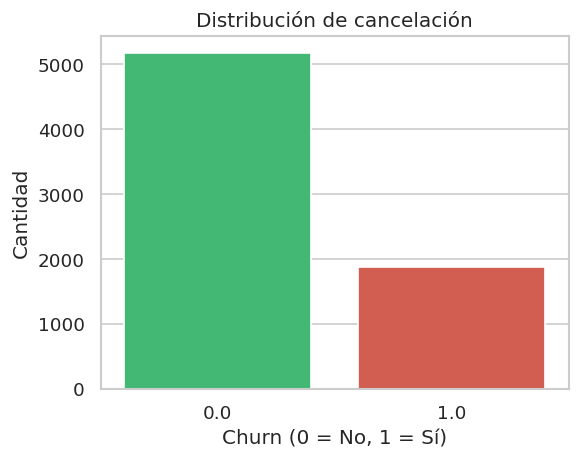

,conteo,porcentaje
Churn,,
0.0,5174,73.46
1.0,1869,26.54


Ratio de desbalance: 2.77


In [78]:
plt.figure(figsize=(5,4))
sns.countplot(data=df_ml, x="Churn", palette=["#2ecc71", "#e74c3c"])
plt.title("Distribución de cancelación")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

conteo_churn = df_ml["Churn"].value_counts()
proporcion_churn = df_ml["Churn"].value_counts(normalize=True) * 100

resumen_churn = pd.DataFrame({
    "conteo": conteo_churn,
    "porcentaje": proporcion_churn.round(2)
}).sort_index()

display(resumen_churn)

ratio = conteo_churn.max() / conteo_churn.min()
print(f"Ratio de desbalance: {ratio:.2f}")


## 6. Correlación y visualizaciones clave


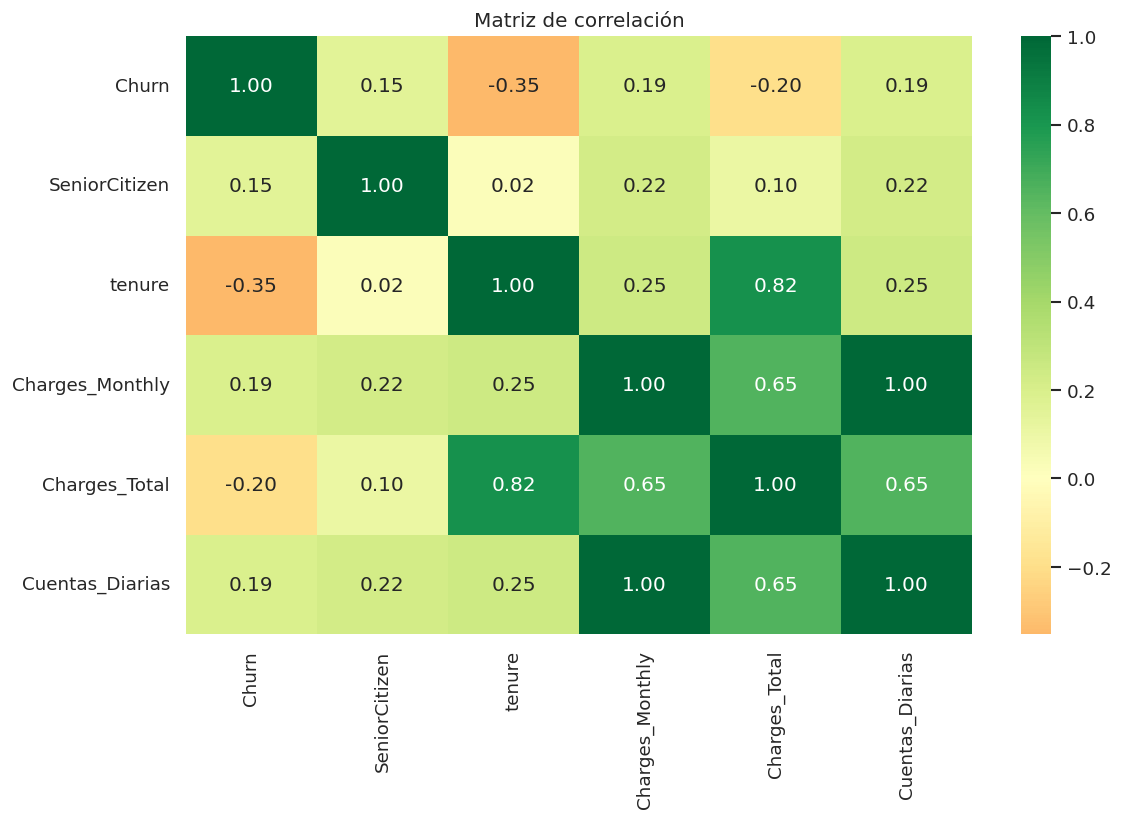

,Correlación con Churn
Churn,1.000000
Charges_Monthly,0.193356
Cuentas_Diarias,0.193356
SeniorCitizen,0.150889
Charges_Total,-0.199034
tenure,-0.352229


In [79]:
numericas = df_ml.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10,7))
corr = df_ml[numericas].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

corr_churn = corr["Churn"].sort_values(ascending=False)
display(corr_churn.to_frame("Correlación con Churn"))


/tmp/ipykernel_958/3529280176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x="Churn", y="tenure", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
/tmp/ipykernel_958/3529280176.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ml, x="Churn", y="Charges_Total", ax=axes[1], palette=["#2ecc71", "#e74c3c"])


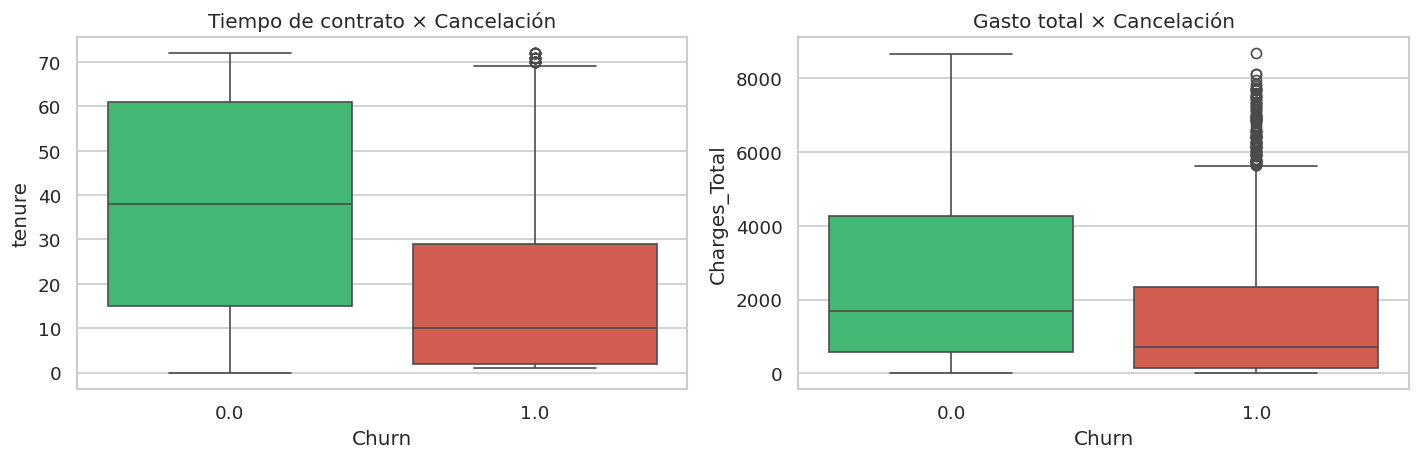

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(data=df_ml, x="Churn", y="tenure", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Tiempo de contrato × Cancelación")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("tenure")

sns.boxplot(data=df_ml, x="Churn", y="Charges_Total", ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Gasto total × Cancelación")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Charges_Total")

plt.tight_layout()
plt.show()


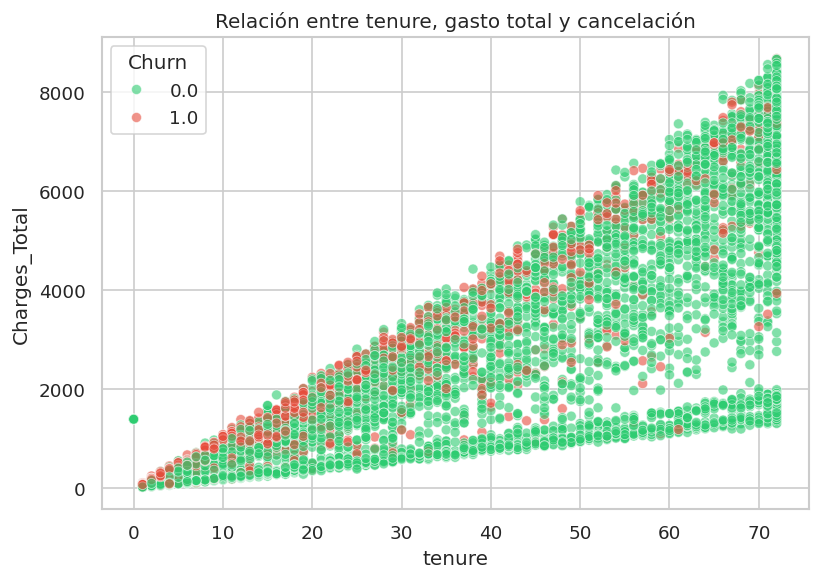

In [81]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_ml,
    x="tenure",
    y="Charges_Total",
    hue="Churn",
    alpha=0.6,
    palette={0:"#2ecc71", 1:"#e74c3c"}
)
plt.title("Relación entre tenure, gasto total y cancelación")
plt.tight_layout()
plt.show()


## 7. Separación entre variables predictoras y objetivo


In [82]:
df_ml_cleaned = df_ml.dropna(subset=['Churn'])
X = df_ml_cleaned.drop(columns=["Churn"])
y = df_ml_cleaned["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

columnas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Variables numéricas:", columnas_numericas)
print("Variables categóricas:", columnas_categoricas)

Train: (4930, 20) (4930,)
Test: (2113, 20) (2113,)
Variables numéricas: ['SeniorCitizen', 'tenure', 'Charges_Monthly', 'Charges_Total', 'Cuentas_Diarias']
Variables categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 8. Codificación de variables categóricas
Se usa one-hot encoding para transformar variables categóricas en variables numéricas.


In [83]:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre_log = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), columnas_numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", ohe)
        ]), columnas_categoricas)
    ]
)

pre_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), columnas_numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", ohe)
        ]), columnas_categoricas)
    ]
)

X_train_log = pre_log.fit_transform(X_train)
X_test_log = pre_log.transform(X_test)

X_train_rf = pre_rf.fit_transform(X_train)
X_test_rf = pre_rf.transform(X_test)

feature_names_log = pre_log.get_feature_names_out()
feature_names_rf = pre_rf.get_feature_names_out()

print("Transformación completada.")
print("Shape Logistic:", X_train_log.shape, X_test_log.shape)
print("Shape RF:", X_train_rf.shape, X_test_rf.shape)


Transformación completada.
Shape Logistic: (4930, 46) (2113, 46)
Shape RF: (4930, 46) (2113, 46)


## 9. Balanceo de clases
Se aplica SMOTE solo sobre el conjunto de entrenamiento para evitar fuga de información.


In [84]:
usar_smote = True

if usar_smote and smote_disponible:
    smote = SMOTE(random_state=42)

    X_train_log_bal, y_train_log_bal = smote.fit_resample(X_train_log, y_train)
    X_train_rf_bal, y_train_rf_bal = smote.fit_resample(X_train_rf, y_train)

    print("SMOTE aplicado.")
    print("\nDistribución original:")
    print(y_train.value_counts())

    print("\nDistribución balanceada Logistic:")
    print(pd.Series(y_train_log_bal).value_counts())

    print("\nDistribución balanceada RF:")
    print(pd.Series(y_train_rf_bal).value_counts())
else:
    X_train_log_bal, y_train_log_bal = X_train_log, y_train
    X_train_rf_bal, y_train_rf_bal = X_train_rf, y_train
    print("SMOTE no disponible. Se continúa sin balanceo sintético.")


SMOTE aplicado.

Distribución original:
Churn
0.0    3622
1.0    1308
Name: count, dtype: int64

Distribución balanceada Logistic:
Churn
0.0    3622
1.0    3622
Name: count, dtype: int64

Distribución balanceada RF:
Churn
0.0    3622
1.0    3622
Name: count, dtype: int64


## 10. Entrenamiento de modelos
Se entrenan dos modelos:
- Regresión Logística, sensible a la escala.
- Random Forest, no sensible a la escala.


In [85]:
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    min_samples_split=5,
    min_samples_leaf=2
)

log_reg.fit(X_train_log_bal, y_train_log_bal)
rf.fit(X_train_rf_bal, y_train_rf_bal)

print("Modelos entrenados correctamente.")


Modelos entrenados correctamente.


## 11. Evaluación de modelos


In [86]:
def evaluar_modelo(nombre, modelo, Xtr, ytr, Xte, yte):
    pred_train = modelo.predict(Xtr)
    pred_test = modelo.predict(Xte)

    resultados = pd.DataFrame({
        "Accuracy_train": [accuracy_score(ytr, pred_train)],
        "Precision_train": [precision_score(ytr, pred_train, zero_division=0)],
        "Recall_train": [recall_score(ytr, pred_train, zero_division=0)],
        "F1_train": [f1_score(ytr, pred_train, zero_division=0)],
        "Accuracy_test": [accuracy_score(yte, pred_test)],
        "Precision_test": [precision_score(yte, pred_test, zero_division=0)],
        "Recall_test": [recall_score(yte, pred_test, zero_division=0)],
        "F1_test": [f1_score(yte, pred_test, zero_division=0)]
    }, index=[nombre])

    return resultados, pred_test

res_log, pred_log = evaluar_modelo(
    "Regresión Logística",
    log_reg,
    X_train_log_bal, y_train_log_bal,
    X_test_log, y_test
)

res_rf, pred_rf = evaluar_modelo(
    "Random Forest",
    rf,
    X_train_rf_bal, y_train_rf_bal,
    X_test_rf, y_test
)

resultados_modelos = pd.concat([res_log, res_rf]).round(4)
display(resultados_modelos)


,Accuracy_train,Precision_train,Recall_train,F1_train,Accuracy_test,Precision_test,Recall_test,F1_test
Regresión Logística,0.7845,0.7620,0.8274,0.7934,0.7459,0.5139,0.7897,0.6226
Random Forest,0.9499,0.9597,0.9393,0.9494,0.7790,0.5925,0.5365,0.5631


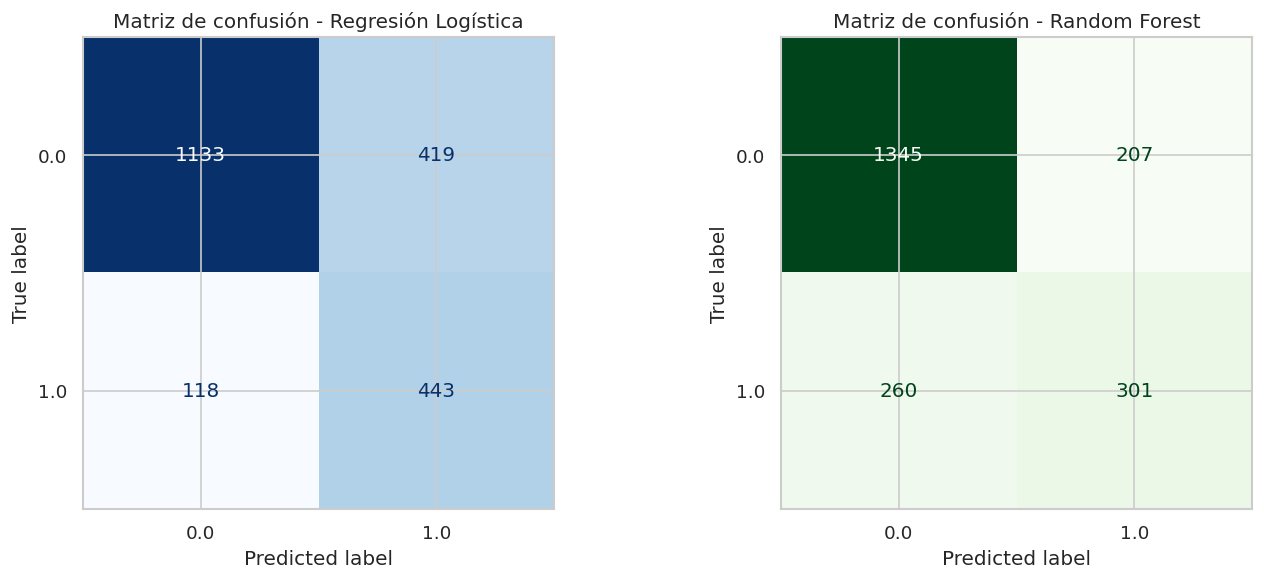

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_log, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Matriz de confusión - Regresión Logística")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_rf, ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Matriz de confusión - Random Forest")

plt.tight_layout()
plt.show()


In [88]:
print("=== Reporte de clasificación: Regresión Logística ===")
print(classification_report(y_test, pred_log, zero_division=0))

print("=== Reporte de clasificación: Random Forest ===")
print(classification_report(y_test, pred_rf, zero_division=0))


=== Reporte de clasificación: Regresión Logística ===
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1552
         1.0       0.51      0.79      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.76      0.72      2113
weighted avg       0.80      0.75      0.76      2113

=== Reporte de clasificación: Random Forest ===
              precision    recall  f1-score   support

         0.0       0.84      0.87      0.85      1552
         1.0       0.59      0.54      0.56       561

    accuracy                           0.78      2113
   macro avg       0.72      0.70      0.71      2113
weighted avg       0.77      0.78      0.78      2113



## 12. Diagnóstico de overfitting o underfitting


In [89]:
def diagnostico_ajuste(f1_train, f1_test):
    gap = f1_train - f1_test
    if gap > 0.10:
        return "Posible overfitting"
    elif f1_train < 0.60 and f1_test < 0.60:
        return "Posible underfitting"
    else:
        return "Generalización razonable"

analisis_ajuste = pd.DataFrame({
    "Modelo": resultados_modelos.index,
    "F1_train": resultados_modelos["F1_train"].values,
    "F1_test": resultados_modelos["F1_test"].values
})

analisis_ajuste["Diagnóstico"] = analisis_ajuste.apply(
    lambda row: diagnostico_ajuste(row["F1_train"], row["F1_test"]),
    axis=1
)

display(analisis_ajuste)


,Modelo,F1_train,F1_test,Diagnóstico
0,Regresión Logística,0.7934,0.6226,Posible overfitting
1,Random Forest,0.9494,0.5631,Posible overfitting


## 13. Variables más relevantes para la predicción


In [90]:
coef_log = pd.Series(log_reg.coef_[0], index=feature_names_log).sort_values()

top_positivas_log = coef_log.tail(15).sort_values(ascending=False)
top_negativas_log = coef_log.head(15).sort_values()

print("Variables que más aumentan la probabilidad de cancelación:")
display(top_positivas_log.to_frame("coeficiente"))

print("Variables que más reducen la probabilidad de cancelación:")
display(top_negativas_log.to_frame("coeficiente"))


Variables que más aumentan la probabilidad de cancelación:


,coeficiente
num__Charges_Total,0.996420
cat__Contract_Month-to-month,0.672265
cat__InternetService_Fiber optic,0.561909
cat__PaymentMethod_Electronic check,0.312529
cat__TechSupport_No,0.203662
cat__StreamingTV_Yes,0.196618
cat__StreamingMovies_Yes,0.194424
cat__OnlineSecurity_No,0.161326
cat__PaperlessBilling_Yes,0.145983
cat__MultipleLines_Yes,0.132648


Variables que más reducen la probabilidad de cancelación:


,coeficiente
num__tenure,-1.725588
cat__Contract_Two year,-0.814350
cat__InternetService_DSL,-0.535495
cat__PaperlessBilling_No,-0.367897
num__Cuentas_Diarias,-0.322810
num__Charges_Monthly,-0.322810
cat__OnlineSecurity_No internet service,-0.248328
cat__OnlineBackup_No internet service,-0.248328
cat__DeviceProtection_No internet service,-0.248328
cat__StreamingMovies_No internet service,-0.248328


In [91]:
imp_rf = pd.Series(rf.feature_importances_, index=feature_names_rf).sort_values(ascending=False).head(20)

print("Variables más importantes según Random Forest:")
display(imp_rf.to_frame("importancia"))


Variables más importantes según Random Forest:


,importancia
cat__Contract_Month-to-month,0.107124
num__tenure,0.078419
cat__PaymentMethod_Electronic check,0.076123
num__Charges_Total,0.072589
cat__OnlineSecurity_No,0.064662
cat__TechSupport_No,0.056070
num__Cuentas_Diarias,0.044662
num__Charges_Monthly,0.044358
cat__OnlineBackup_No,0.035271
cat__Contract_Two year,0.031150


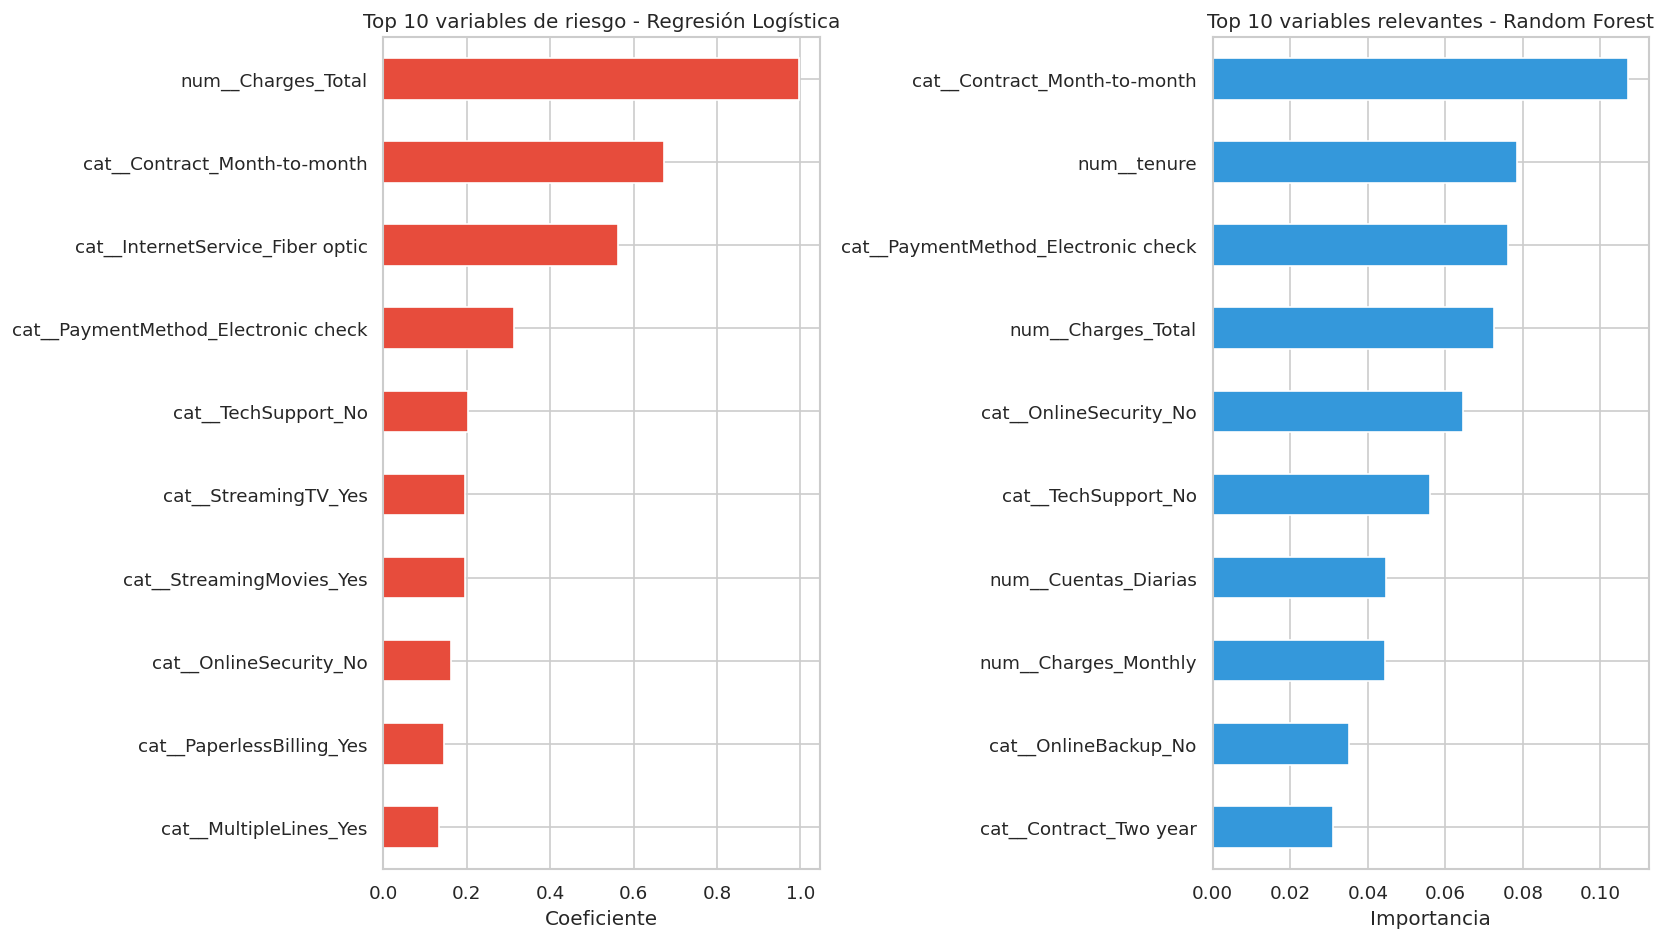

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14,8))

top_positivas_log.head(10).sort_values().plot(kind="barh", ax=axes[0], color="#e74c3c")
axes[0].set_title("Top 10 variables de riesgo - Regresión Logística")
axes[0].set_xlabel("Coeficiente")

imp_rf.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#3498db")
axes[1].set_title("Top 10 variables relevantes - Random Forest")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.show()


## 14. Informe final


In [93]:
mejor_modelo = resultados_modelos["F1_test"].idxmax()

factores_riesgo = top_positivas_log.head(5).index.tolist()
factores_proteccion = top_negativas_log.head(5).index.tolist()
factores_rf = imp_rf.head(5).index.tolist()

print("="*80)
print("INFORME FINAL - TELECOM X")
print("="*80)
print(f"Mejor modelo según F1-score en prueba: {mejor_modelo}")
print()

print("1. Desbalance de clases")
print("- La variable objetivo presenta una proporción desigual entre clientes que permanecen y clientes que cancelan.")
print("- Se evaluó el desbalance y, si estuvo disponible, se aplicó SMOTE solo en entrenamiento.")
print()

print("2. Comparación de modelos")
display(resultados_modelos)

print("3. Diagnóstico de ajuste")
display(analisis_ajuste)

print("4. Variables más importantes")
print("Factores que más aumentan el riesgo de cancelación según Regresión Logística:")
for var in factores_riesgo:
    print("-", var)

print("\nFactores asociados a mayor retención según Regresión Logística:")
for var in factores_proteccion:
    print("-", var)

print("\nVariables más importantes según Random Forest:")
for var in factores_rf:
    print("-", var)

print()
print("5. Conclusiones de negocio")
print("- Los clientes con señales de mayor riesgo deben ser priorizados en campañas de retención.")
print("- El tipo de contrato, la antigüedad del cliente, el gasto total y algunos servicios contratados suelen tener alto impacto en la cancelación.")
print("- Se recomienda ofrecer incentivos para contratos de mayor duración, reforzar soporte técnico y diseñar acciones tempranas para clientes nuevos.")
print("- También conviene monitorear segmentos con mayor probabilidad de churn mediante el modelo con mejor F1-score.")
print("="*80)


INFORME FINAL - TELECOM X
Mejor modelo según F1-score en prueba: Regresión Logística

1. Desbalance de clases
- La variable objetivo presenta una proporción desigual entre clientes que permanecen y clientes que cancelan.
- Se evaluó el desbalance y, si estuvo disponible, se aplicó SMOTE solo en entrenamiento.

2. Comparación de modelos


,Accuracy_train,Precision_train,Recall_train,F1_train,Accuracy_test,Precision_test,Recall_test,F1_test
Regresión Logística,0.7845,0.7620,0.8274,0.7934,0.7459,0.5139,0.7897,0.6226
Random Forest,0.9499,0.9597,0.9393,0.9494,0.7790,0.5925,0.5365,0.5631


3. Diagnóstico de ajuste


,Modelo,F1_train,F1_test,Diagnóstico
0,Regresión Logística,0.7934,0.6226,Posible overfitting
1,Random Forest,0.9494,0.5631,Posible overfitting


4. Variables más importantes
Factores que más aumentan el riesgo de cancelación según Regresión Logística:
- num__Charges_Total
- cat__Contract_Month-to-month
- cat__InternetService_Fiber optic
- cat__PaymentMethod_Electronic check
- cat__TechSupport_No

Factores asociados a mayor retención según Regresión Logística:
- num__tenure
- cat__Contract_Two year
- cat__InternetService_DSL
- cat__PaperlessBilling_No
- num__Cuentas_Diarias

Variables más importantes según Random Forest:
- cat__Contract_Month-to-month
- num__tenure
- cat__PaymentMethod_Electronic check
- num__Charges_Total
- cat__OnlineSecurity_No

5. Conclusiones de negocio
- Los clientes con señales de mayor riesgo deben ser priorizados en campañas de retención.
- El tipo de contrato, la antigüedad del cliente, el gasto total y algunos servicios contratados suelen tener alto impacto en la cancelación.
- Se recomienda ofrecer incentivos para contratos de mayor duración, reforzar soporte técnico y diseñar acciones tempranas para

## 15. Informe final Escrito

### 1. Objetivo del proyecto

El objetivo de este análisis fue identificar los principales factores asociados a la cancelación de clientes en Telecom X y desarrollar modelos predictivos capaces de estimar el riesgo de churn a partir de variables demográficas, contractuales, de servicios y de facturación.

---

### 2. Preparación y tratamiento de datos

Para preparar la base de datos para el modelado predictivo, se realizó un proceso de limpieza y transformación que incluyó la eliminación de variables irrelevantes para la predicción, como el identificador único del cliente (`customerID`).  
Posteriormente, las variables categóricas fueron transformadas a formato numérico mediante **one-hot encoding**, con el fin de hacerlas compatibles con los algoritmos de machine learning.

También se verificó la distribución de la variable objetivo (`Churn`) y se detectó un desbalance de clases en el conjunto de entrenamiento.  
En la muestra original de entrenamiento había **3,622 clientes que no cancelaron** y **1,308 que sí cancelaron**, por lo que se aplicó la técnica **SMOTE** exclusivamente sobre los datos de entrenamiento para balancear ambas clases en **3,622 observaciones por categoría**.

Además, se aplicó estandarización únicamente en el modelo de Regresión Logística, dado que este algoritmo es sensible a la escala de las variables.  
En cambio, para Random Forest no fue necesaria la normalización, ya que los modelos basados en árboles no dependen de la magnitud de los datos para realizar sus divisiones.

---

### 3. Análisis exploratorio y hallazgos iniciales

El análisis exploratorio permitió observar que la cancelación de clientes no responde a una sola variable, sino a una combinación de factores relacionados con la permanencia, el tipo de contrato, los servicios contratados y la estructura de cobros.  
La matriz de correlación y los gráficos de relación entre variables mostraron que el tiempo de permanencia (`tenure`) es uno de los factores más importantes, ya que los clientes con menor antigüedad presentan una mayor tendencia a cancelar.

De forma complementaria, el análisis visual entre **tiempo de contrato y cancelación** y entre **gasto total y cancelación** reforzó la idea de que los clientes más nuevos y con ciertas condiciones contractuales específicas concentran una mayor proporción de churn.  
Estos patrones justificaron la construcción de modelos predictivos orientados no solo a clasificar clientes, sino también a entender qué variables explican mejor el fenómeno.

---

### 4. Modelos predictivos desarrollados

Se entrenaron dos modelos de clasificación supervisada para predecir la cancelación de clientes:

- **Regresión Logística**
- **Random Forest**

La comparación entre ambos modelos se realizó utilizando las métricas de desempeño más relevantes para clasificación: **accuracy**, **precision**, **recall**, **F1-score** y **matriz de confusión**.

En el conjunto de prueba, la **Regresión Logística** obtuvo los siguientes resultados:

- Accuracy: **0.7459**
- Precision: **0.5139**
- Recall: **0.7897**
- F1-score: **0.6226**

Por su parte, el modelo de **Random Forest** presentó los siguientes resultados:

- Accuracy: **0.7790**
- Precision: **0.5925**
- Recall: **0.5365**
- F1-score: **0.5631**

---

### 5. Comparación de desempeño

Aunque Random Forest alcanzó una exactitud general ligeramente superior, la **Regresión Logística** mostró un mejor equilibrio entre las métricas más importantes para este problema, especialmente en **recall** y **F1-score** de la clase positiva.  
Esto significa que la Regresión Logística fue más efectiva para detectar clientes que efectivamente cancelarían el servicio.

En un problema de churn, esta capacidad resulta especialmente valiosa, ya que el costo de no identificar a un cliente en riesgo suele ser mayor que el de generar una alerta adicional sobre un cliente que finalmente no cancela.  
Por esta razón, el modelo con mayor utilidad práctica para el negocio no necesariamente es el de mayor accuracy, sino aquel que recupera mejor los casos reales de cancelación.

---

### 6. Análisis de overfitting y generalización

El análisis del rendimiento en entrenamiento y prueba mostró indicios de **overfitting** en ambos modelos, aunque este efecto fue mucho más evidente en Random Forest.  
La Regresión Logística pasó de un **F1-score de 0.7934 en entrenamiento** a **0.6226 en prueba**, mientras que Random Forest descendió de **0.9494 a 0.5631**.

Esta diferencia sugiere que Random Forest aprendió con excesivo detalle los patrones del conjunto de entrenamiento, reduciendo su capacidad de generalización frente a datos no vistos.  
En contraste, la Regresión Logística mostró una caída menor y un comportamiento más estable, lo que refuerza su conveniencia como modelo final del proyecto.

---

### 7. Variables más relevantes en la predicción

El análisis de coeficientes de la Regresión Logística permitió identificar las variables con mayor influencia sobre la probabilidad de cancelación.  
Entre los factores que más aumentaron el riesgo de churn destacaron:

- `Charges_Total`
- `Contract_Month-to-month`
- `InternetService_Fiber optic`
- `PaymentMethod_Electronic check`
- `TechSupport_No`

También aparecieron como variables asociadas a mayor riesgo la ausencia de servicios de seguridad, facturación electrónica y algunas configuraciones de entretenimiento o líneas múltiples.  
Esto sugiere que la cancelación está fuertemente relacionada con clientes que tienen contratos menos estables, menor nivel de acompañamiento técnico y ciertas condiciones de servicio que podrían afectar su percepción de valor.

Por otro lado, las variables que más contribuyeron a reducir la probabilidad de cancelación fueron:

- `tenure`
- `Contract_Two year`
- `InternetService_DSL`
- `PaperlessBilling_No`
- `Charges_Monthly`
- `Cuentas_Diarias`

En términos generales, estos resultados indican que los clientes con mayor antigüedad y contratos más extensos presentan una probabilidad significativamente menor de abandonar la compañía.

---

### 8. Conclusiones de negocio

Los hallazgos del análisis permiten concluir que la cancelación de clientes en Telecom X está principalmente asociada a contratos mensuales, baja permanencia, servicio de fibra óptica, pago mediante cheque electrónico y ausencia de soporte técnico.  
En cambio, los clientes con contratos de largo plazo y mayor antigüedad muestran una relación más fuerte con la permanencia.

A partir de estos resultados, se proponen las siguientes estrategias de retención:

- Diseñar campañas de fidelización para clientes con baja antigüedad.
- Incentivar la migración desde contratos mensuales hacia contratos anuales o bianuales.
- Revisar la experiencia de los usuarios de fibra óptica para detectar posibles causas de insatisfacción.
- Ofrecer planes con soporte técnico o seguridad digital como valor agregado.
- Monitorear con mayor atención a los clientes que utilizan cheque electrónico como método de pago.

---

### 9. Conclusión final

Considerando el desempeño obtenido, la **Regresión Logística** fue el modelo más adecuado para este problema.  
Si bien no obtuvo la mayor accuracy, sí presentó el mejor equilibrio entre capacidad predictiva, interpretación y detección efectiva de clientes en riesgo de cancelación.

Además, su estructura permite interpretar con claridad el impacto de cada variable, lo que facilita traducir los resultados del análisis en acciones concretas de negocio.  
De este modo, el proyecto no solo cumple una función predictiva, sino también estratégica, al aportar evidencia útil para orientar decisiones de retención de clientes.
